Bước 1: Tiền xử lý dữ liệu chuỗi thời gian

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os, yaml
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.append(os.path.abspath(os.path.join('..')))

from src.models.forecasting import run_arima_forecast, run_holt_winters_forecast
from src.evaluation.metrics import calculate_ts_metrics, detect_ts_outliers, evaluate_forecast, analyze_residuals, detect_forecast_outliers 
from src.visualization.plots import plot_acf_pacf, plot_ts_analysis
from src.data.loader import load_data, add_time_features, prepare_ts_index, resample_weather_data

# Load Config
with open('../configs/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    
# Load data
df = pd.read_csv(f"../{config['processed_data_path']}")

# Time Series
ts_df = prepare_ts_index(df)

# Kiểm tra thử Index
print(f"Kiểu Index hiện tại: {type(ts_df.index)}")
# Kết quả mong muốn: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

# Tiến hành Resample
target = config['time_series']['target']
ts_data = resample_weather_data(ts_df, target)

Kiểu Index hiện tại: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


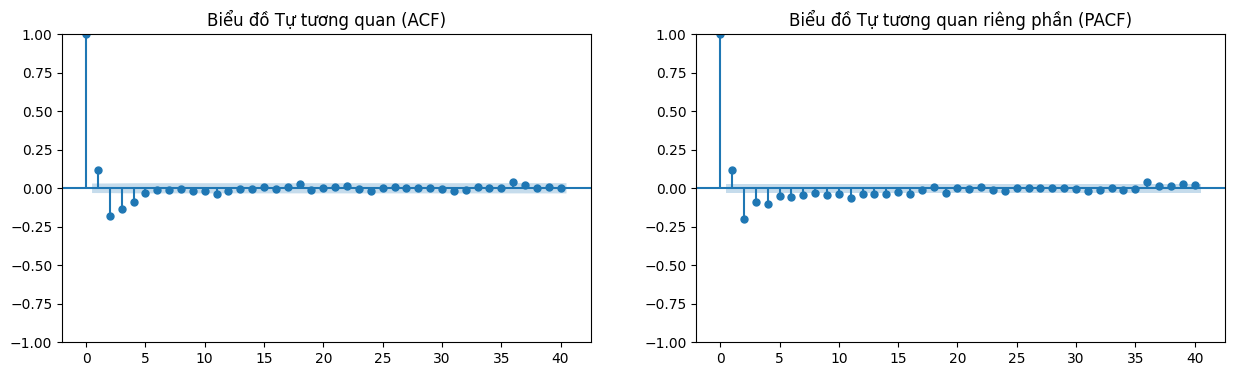

In [2]:
# Kiểm tra ACF/PACF (Phân tích chuỗi trước khi dự báo)
ts_diff = ts_data.diff().dropna()
plot_ts_analysis(ts_diff)

In [3]:
# Chia Train/Test
test_days = config['time_series']['test_size']
train, test = ts_data[:-test_days], ts_data[-test_days:]

In [4]:
#  Huấn luyện & Dự báo

arima_pred, arima_mod = run_arima_forecast(train, len(test), order=(1,1,1))
hw_pred, hw_mod = run_holt_winters_forecast(train, len(test))

D:\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [5]:
# So sánh kết quả
arima_metrics = evaluate_forecast(test, arima_pred)
hw_metrics = evaluate_forecast(test, hw_pred)

print(f"ARIMA: {arima_metrics}")
print(f"Holt-Winters: {hw_metrics}")

ARIMA: {'MAE': 1.6421491476928873, 'RMSE': np.float64(1.8237546416099604)}
Holt-Winters: {'MAE': 1.7874243482510772, 'RMSE': np.float64(2.130214998252357)}


In [6]:
# Phân tích Residual & Outlier cho model tốt nhất 
res = analyze_residuals(test, hw_pred)
outliers = detect_forecast_outliers(res)

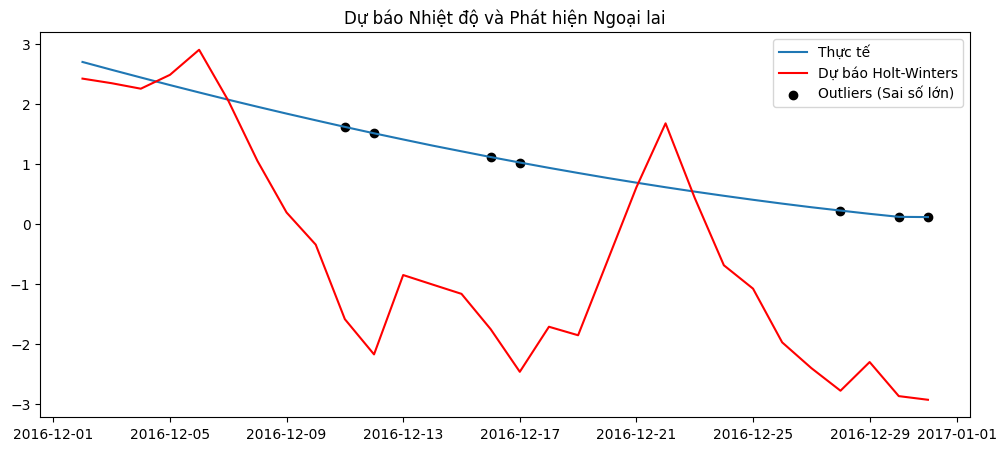

In [7]:
# Trực quan hóa kết quả
plt.figure(figsize=(12, 5))
plt.plot(test, label='Thực tế')
plt.plot(hw_pred, label='Dự báo Holt-Winters', color='red')
plt.scatter(outliers.index, test.loc[outliers.index], color='black', label='Outliers (Sai số lớn)')
plt.legend()
plt.title("Dự báo Nhiệt độ và Phát hiện Ngoại lai")
plt.show()

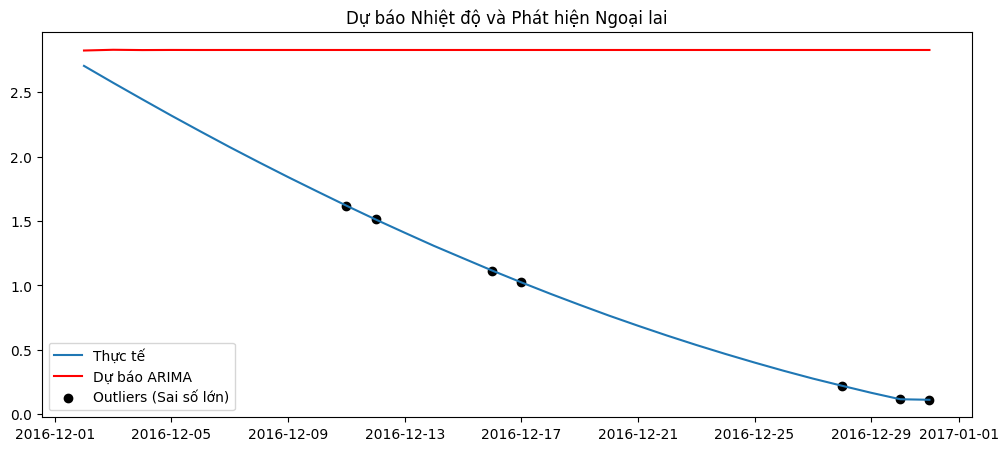

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(test, label='Thực tế')
plt.plot(arima_pred, label='Dự báo ARIMA', color='red')
plt.scatter(outliers.index, test.loc[outliers.index], color='black', label='Outliers (Sai số lớn)')
plt.legend()
plt.title("Dự báo Nhiệt độ và Phát hiện Ngoại lai")
plt.show()

📦 Đã lưu mô hình chuỗi thời gian: ../outputs/models/holt_winters_weather_v1.pkl
🖼️ Đã lưu biểu đồ tại: ..\outputs/figures\ts_forecast_result.png
⚠️ Đã lưu danh sách các điểm ngoại lai dự báo.


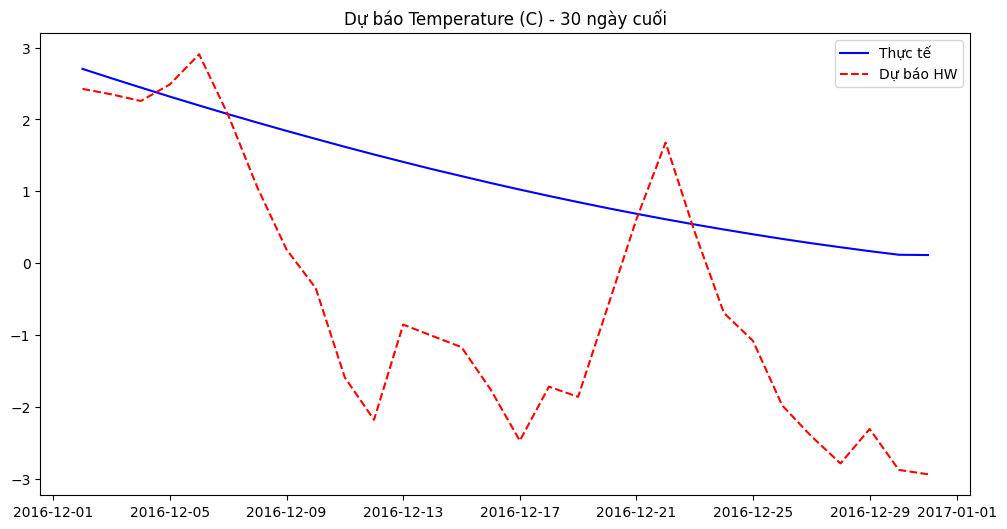

In [9]:
from src.models.handler import save_timeseries_model, save_metrics_to_table

# 1. Lưu mô hình tốt nhất (Ví dụ Holt-Winters)
# Lưu ý: hw_mod là đối tượng kết quả sau khi .fit()
save_timeseries_model(hw_mod, "holt_winters_weather_v1", config)

# 2. Lưu bảng so sánh sai số MAE/RMSE
# Gộp các metrics của cả 2 model để so sánh trong báo cáo
comparison_metrics = {
    "Model": ["ARIMA", "Holt-Winters"],
    "MAE": [arima_metrics['MAE'], hw_metrics['MAE']],
    "RMSE": [arima_metrics['RMSE'], hw_metrics['RMSE']]
}
df_comp = pd.DataFrame(comparison_metrics)
df_comp.to_csv("../outputs/tables/ts_model_comparison.csv", index=False)

# 3. Lưu biểu đồ dự báo vào outputs/figures/
plt.figure(figsize=(12, 6))
plt.plot(test, label='Thực tế', color='blue')
plt.plot(hw_pred, label='Dự báo HW', color='red', linestyle='--')
plt.title(f"Dự báo {target} - 30 ngày cuối")
plt.legend()

# Đường dẫn lưu ảnh
# Kiểm tra và tạo thư mục nếu chưa có
fig_dir = os.path.join("..", config['outputs'].get('figures', 'outputs/figures'))
os.makedirs(fig_dir, exist_ok=True)

# Đường dẫn lưu ảnh cụ thể
fig_path = os.path.join(fig_dir, "ts_forecast_result.png")

plt.savefig(fig_path)
print(f"🖼️ Đã lưu biểu đồ tại: {fig_path}")


# 4. Lưu danh sách Outliers (nếu có) để phân tích cực trị
if not outliers.empty:
    outliers.to_csv("../outputs/tables/ts_forecast_outliers.csv")
    print("⚠️ Đã lưu danh sách các điểm ngoại lai dự báo.")